# 🏥 MedFácil Clínicas — Análise Exploratória de Dados (EDA)
**Projeto de Extensão de Sistemas Inteligentes**  
Ciência da Computação + Sistemas de Informação · Turmas 43+44+185 · Santo Amaro  
Disciplina: Análise de Dados (Python/ETL)  
Maio/2026

---

Este notebook realiza a Análise Exploratória de Dados (EDA) sobre o dataset processado pelo ETL (`01_etl.py`).  
O objetivo é compreender a estrutura dos dados, identificar padrões e validar as hipóteses que fundamentam o modelo PLI.


## 0. Configuração e Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuração visual
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
sns.set_palette('Blues_r')

print('Bibliotecas importadas com sucesso!')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')


Bibliotecas importadas com sucesso!
Pandas  : 3.0.3
NumPy   : 2.4.5


## 1. Carregamento do Dataset

In [2]:
df = pd.read_csv('data/processed/healthcare_clean.csv')
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date']    = pd.to_datetime(df['Discharge Date'])

print(f'Shape    : {df.shape}')
print(f'Período  : {df["Year"].min()} – {df["Year"].max()}')
print(f'Colunas  : {list(df.columns)}')


Shape    : (55500, 24)
Período  : 2019 – 2024
Colunas  : ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results', 'Length of Stay (days)', 'Hour of Admission', 'Shift', 'Wait Time (min)', 'Month', 'Year', 'Quarter', 'Weekday', 'Age Group', 'Patient ID']


In [3]:
df.head(5)


,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,...,Length of Stay (days),Hour of Admission,Shift,Wait Time (min),Month,Year,Quarter,Weekday,Age Group,Patient ID
0,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons And Miller,Blue Cross,18856.281306,328,...,2,6,Manhã,76,1,2024,1,Wednesday,19–35,PAC-A0231BCE
1,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,...,6,19,Tarde,5,8,2019,3,Tuesday,51–65,PAC-FBB40DAC
2,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook Plc,Aetna,27955.096079,205,...,15,14,Tarde,23,9,2022,3,Thursday,65+,PAC-080084B4
3,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.782410,450,...,30,10,Manhã,64,11,2020,4,Wednesday,19–35,PAC-C9A81054
4,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,...,20,7,Manhã,74,9,2022,3,Monday,36–50,PAC-70FA69E8


In [4]:
df.dtypes


Age                               int64
Gender                              str
Blood Type                          str
Medical Condition                   str
Date of Admission        datetime64[us]
Doctor                              str
Hospital                            str
Insurance Provider                  str
Billing Amount                  float64
Room Number                       int64
Admission Type                      str
Discharge Date           datetime64[us]
Medication                          str
Test Results                        str
Length of Stay (days)             int64
Hour of Admission                 int64
Shift                               str
Wait Time (min)                   int64
Month                             int64
Year                              int64
Quarter                           int64
Weekday                             str
Age Group                           str
Patient ID                          str
dtype: object

## 2. Qualidade dos Dados

Verificação de valores nulos, duplicatas e estatísticas descritivas básicas.


In [5]:
# Valores nulos
nulls = df.isnull().sum()
print('Valores nulos por coluna:')
print(nulls[nulls > 0] if nulls.sum() > 0 else 'Nenhum valor nulo encontrado. ✓')


Valores nulos por coluna:
Nenhum valor nulo encontrado. ✓


In [6]:
# Duplicatas
dupes = df.duplicated().sum()
print(f'Linhas duplicadas: {dupes}')


Linhas duplicadas: 1


In [7]:
# Estatísticas descritivas — colunas numéricas
df[['Age', 'Billing Amount', 'Length of Stay (days)', 'Wait Time (min)']].describe().round(2)


,Age,Billing Amount,Length of Stay (days),Wait Time (min)
count,55500.00,55500.00,55500.00,55500.00
mean,51.54,25539.32,15.51,58.89
std,19.60,14211.45,8.66,45.48
min,13.00,-2008.49,1.00,5.00
25%,35.00,13241.22,8.00,23.00
50%,52.00,25538.07,15.00,47.00
75%,68.00,37820.51,23.00,82.00
max,89.00,52764.28,30.00,179.00


## 3. Distribuição das Variáveis Categóricas

Análise de frequência das variáveis categóricas mais relevantes para o projeto.


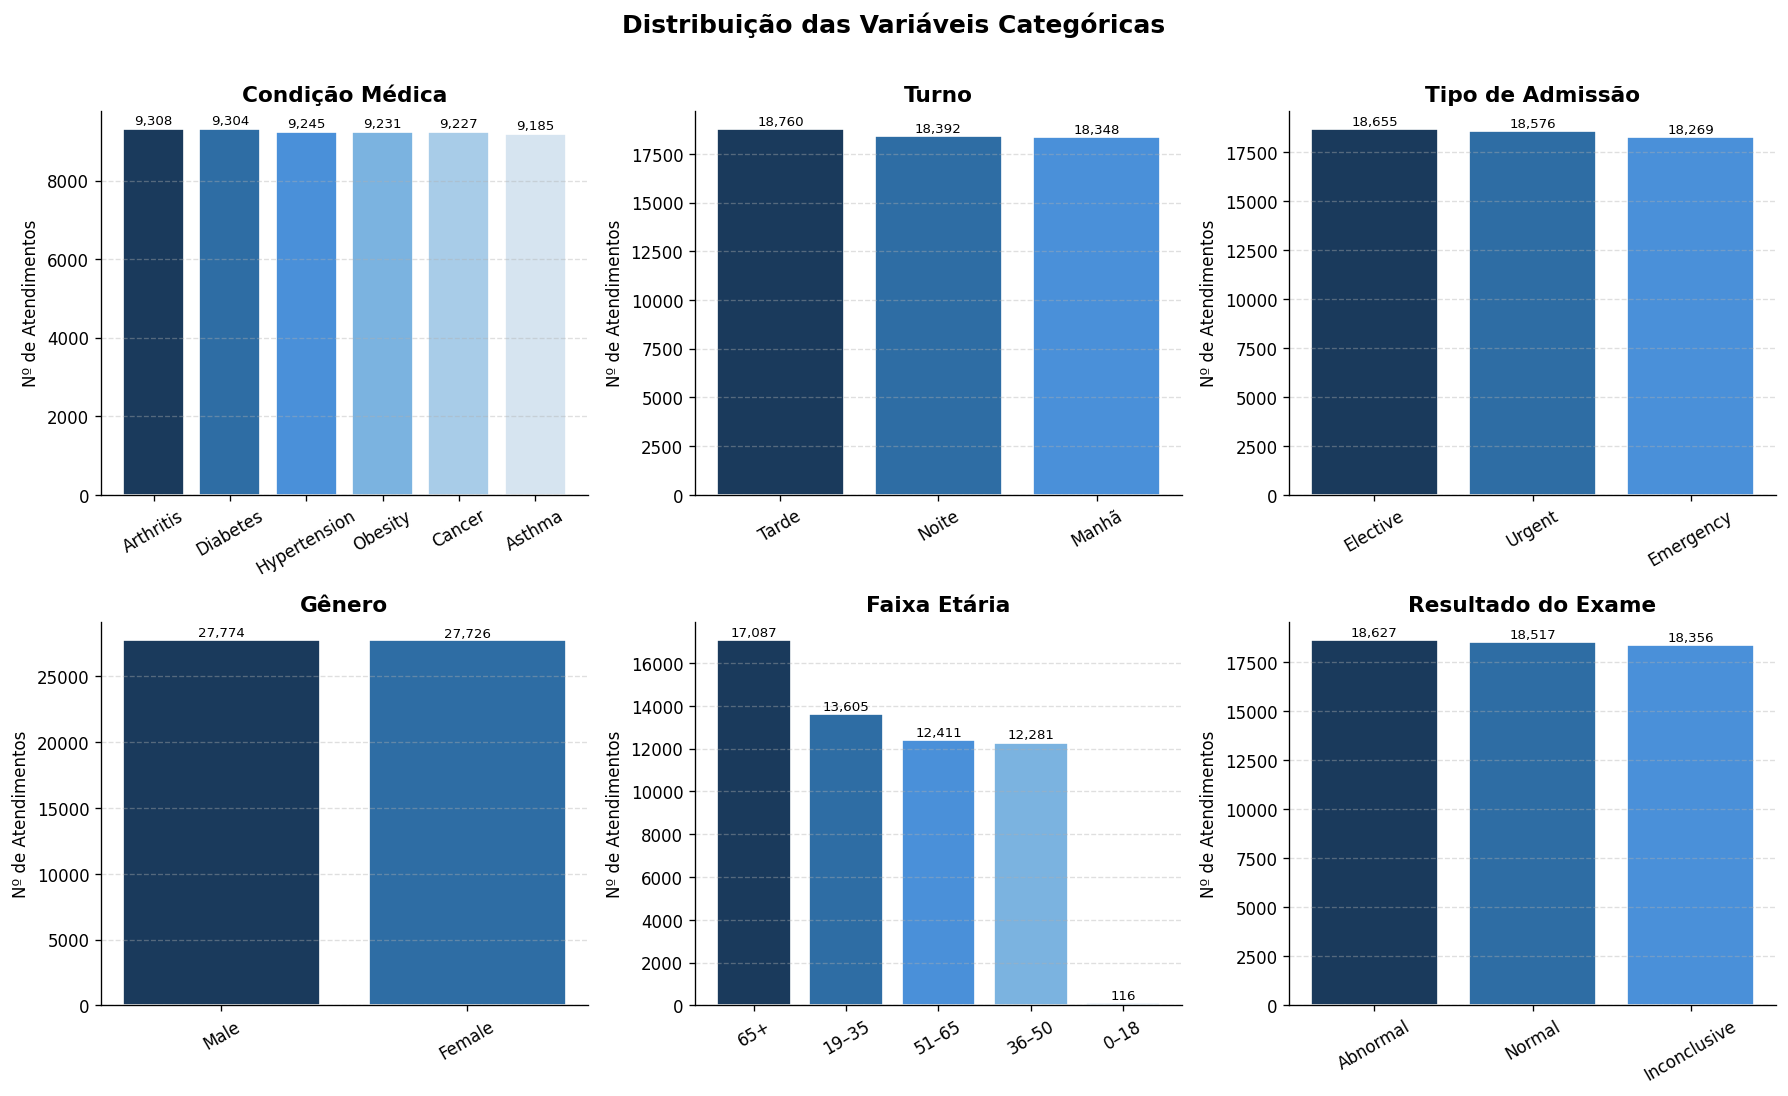

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Distribuição das Variáveis Categóricas', fontsize=15, fontweight='bold', y=1.01)

cats = [
    ('Medical Condition', 'Condição Médica'),
    ('Shift',             'Turno'),
    ('Admission Type',    'Tipo de Admissão'),
    ('Gender',            'Gênero'),
    ('Age Group',         'Faixa Etária'),
    ('Test Results',      'Resultado do Exame'),
]

colors = ['#1A3A5C', '#2E6DA4', '#4A90D9', '#7BB3E0', '#A8CCE8', '#D6E4F0']

for ax, (col, label) in zip(axes.flatten(), cats):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel('Nº de Atendimentos')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('output/charts/eda_categoricas.png', bbox_inches='tight', dpi=130)
plt.show()


## 4. Análise do Tempo de Espera

O tempo de espera (Wait Time) é o KPI 1 do projeto. Analisamos sua distribuição e relação com variáveis-chave.


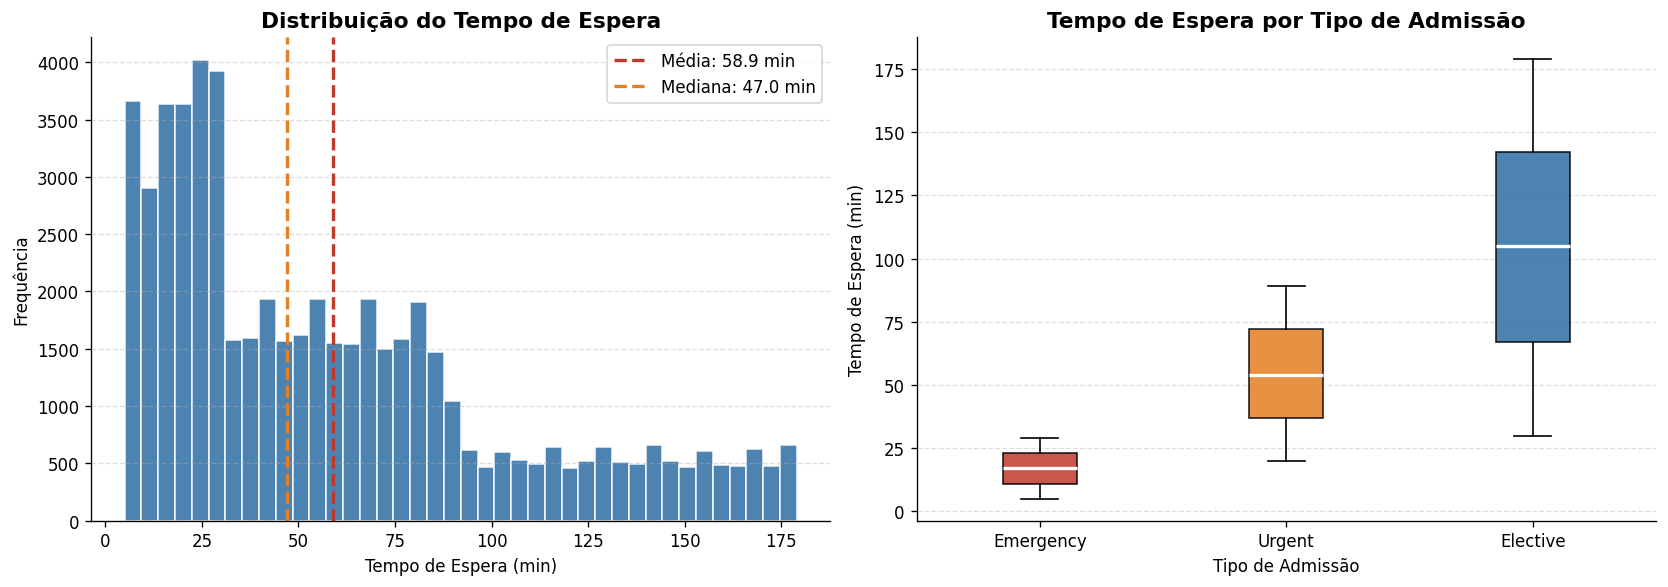


Estatísticas por Tipo de Admissão:
                 mean  median   std  min  max
Admission Type                               
Elective        104.5   105.0  43.4   30  179
Emergency        17.1    17.0   7.3    5   29
Urgent           54.2    54.0  20.2   20   89


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['Wait Time (min)'], bins=40, color='#2E6DA4', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Wait Time (min)'].mean(), color='#C0392B', linestyle='--', linewidth=2,
                 label=f'Média: {df["Wait Time (min)"].mean():.1f} min')
axes[0].axvline(df['Wait Time (min)'].median(), color='#E67E22', linestyle='--', linewidth=2,
                 label=f'Mediana: {df["Wait Time (min)"].median():.1f} min')
axes[0].set_title('Distribuição do Tempo de Espera')
axes[0].set_xlabel('Tempo de Espera (min)')
axes[0].set_ylabel('Frequência')
axes[0].legend()
axes[0].yaxis.grid(True, linestyle='--', alpha=0.4)

# Boxplot por tipo de admissão
order = ['Emergency', 'Urgent', 'Elective']
colors_box = ['#C0392B', '#E67E22', '#2E6DA4']
data_box = [df[df['Admission Type'] == t]['Wait Time (min)'].values for t in order]
bp = axes[1].boxplot(data_box, patch_artist=True, notch=False,
                     medianprops=dict(color='white', linewidth=2))
for patch, cor in zip(bp['boxes'], colors_box):
    patch.set_facecolor(cor)
    patch.set_alpha(0.85)
axes[1].set_xticklabels(order)
axes[1].set_title('Tempo de Espera por Tipo de Admissão')
axes[1].set_xlabel('Tipo de Admissão')
axes[1].set_ylabel('Tempo de Espera (min)')
axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('output/charts/eda_tempo_espera.png', bbox_inches='tight', dpi=130)
plt.show()

print('\nEstatísticas por Tipo de Admissão:')
print(df.groupby('Admission Type')['Wait Time (min)'].agg(['mean','median','std','min','max']).round(1))


## 5. Análise do Tempo de Internação

O Length of Stay (dias de internação) é uma variável operacional importante para o planejamento de leitos.


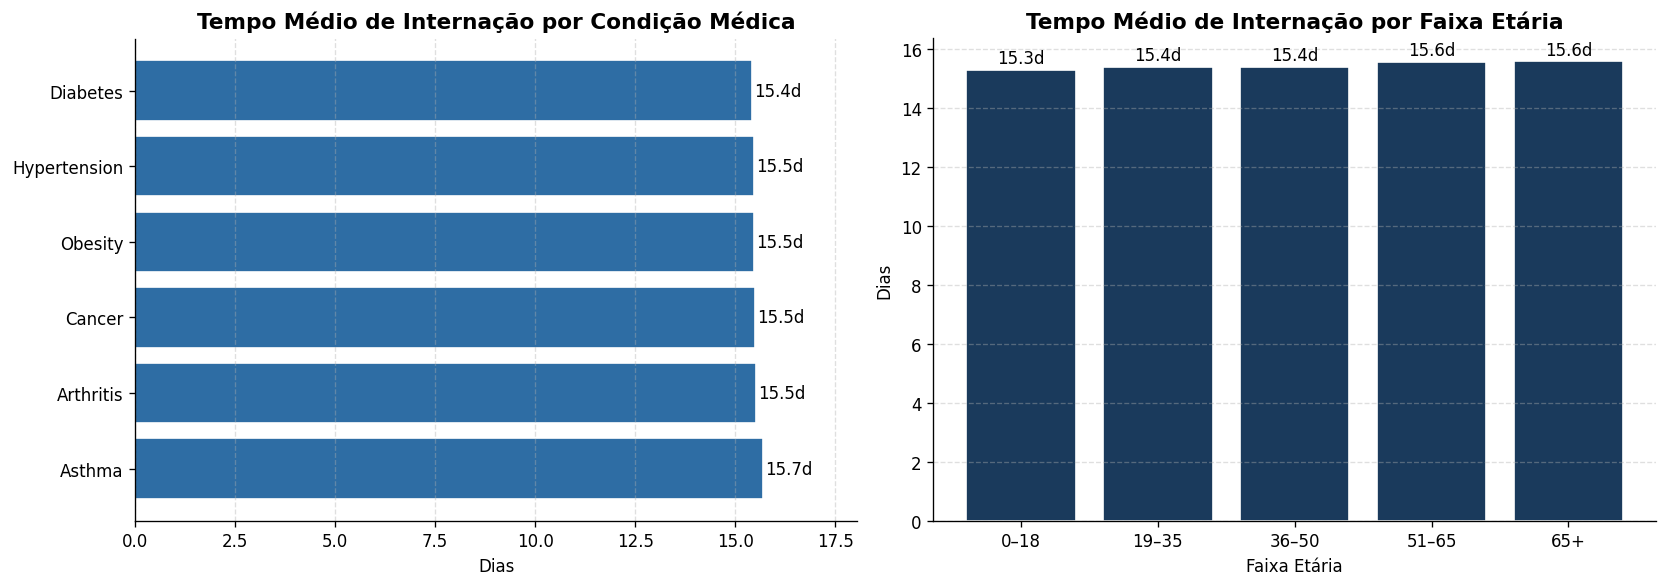

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por condição médica
los_cond = df.groupby('Medical Condition')['Length of Stay (days)'].mean().sort_values(ascending=False)
axes[0].barh(los_cond.index, los_cond.values, color='#2E6DA4', edgecolor='white')
for i, v in enumerate(los_cond.values):
    axes[0].text(v + 0.05, i, f'{v:.1f}d', va='center', fontsize=10)
axes[0].set_title('Tempo Médio de Internação por Condição Médica')
axes[0].set_xlabel('Dias')
axes[0].xaxis.grid(True, linestyle='--', alpha=0.4)
axes[0].set_xlim(0, los_cond.max() * 1.15)

# Por faixa etária
age_order = ['0–18', '19–35', '36–50', '51–65', '65+']
los_age = df.groupby('Age Group', observed=True)['Length of Stay (days)'].mean().reindex(age_order)
axes[1].bar(los_age.index, los_age.values, color='#1A3A5C', edgecolor='white')
for i, (idx, v) in enumerate(los_age.items()):
    axes[1].text(i, v + 0.1, f'{v:.1f}d', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Tempo Médio de Internação por Faixa Etária')
axes[1].set_xlabel('Faixa Etária')
axes[1].set_ylabel('Dias')
axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('output/charts/eda_internacao.png', bbox_inches='tight', dpi=130)
plt.show()


## 6. Análise de Sazonalidade

Padrões temporais que fundamentam a necessidade de alocação dinâmica de médicos (base do modelo PLI).


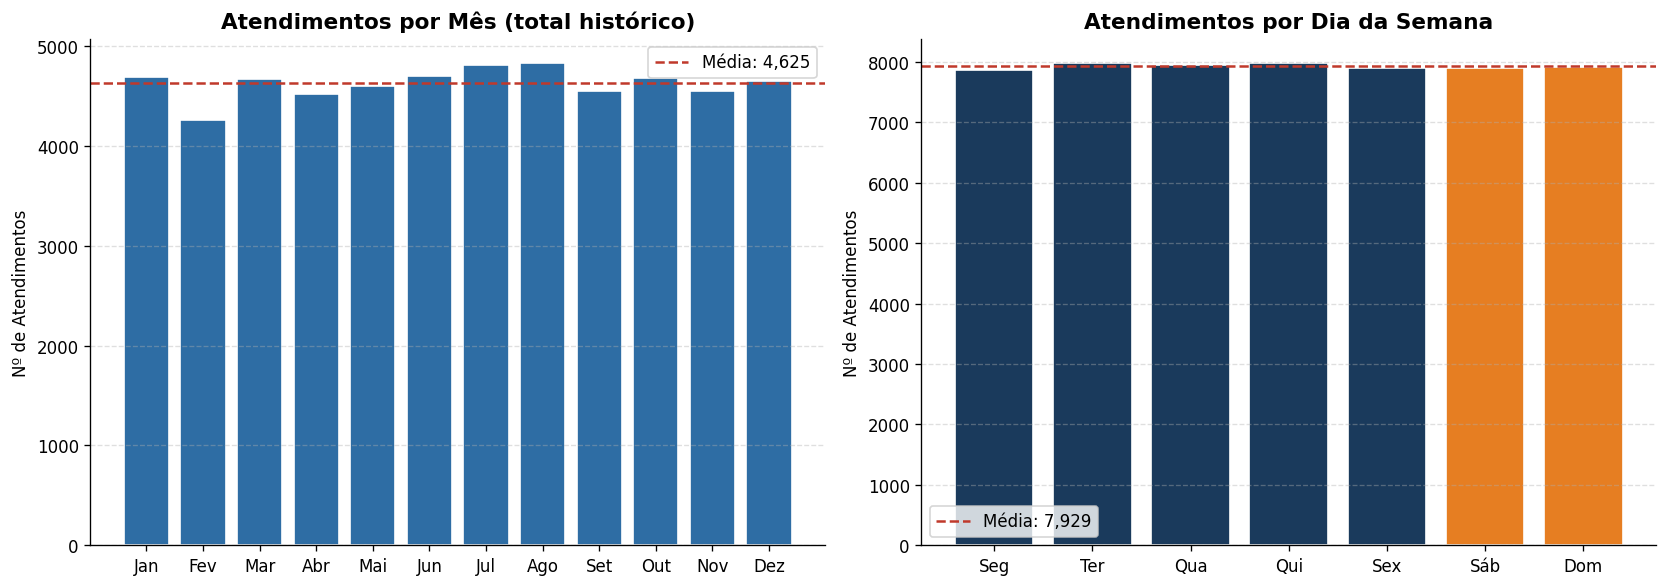

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por mês
mes_labels = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
atend_mes = df.groupby('Month').size()
axes[0].bar(atend_mes.index, atend_mes.values, color='#2E6DA4', edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(mes_labels)
axes[0].set_title('Atendimentos por Mês (total histórico)')
axes[0].set_ylabel('Nº de Atendimentos')
axes[0].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[0].axhline(atend_mes.mean(), color='#C0392B', linestyle='--', linewidth=1.5,
                 label=f'Média: {atend_mes.mean():,.0f}')
axes[0].legend()

# Por dia da semana
dia_order_en = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dia_order_pt = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']
atend_dia = df.groupby('Weekday').size().reindex(dia_order_en)
colors_dia = ['#1A3A5C']*5 + ['#E67E22']*2
axes[1].bar(dia_order_pt, atend_dia.values, color=colors_dia, edgecolor='white')
axes[1].set_title('Atendimentos por Dia da Semana')
axes[1].set_ylabel('Nº de Atendimentos')
axes[1].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[1].axhline(atend_dia.mean(), color='#C0392B', linestyle='--', linewidth=1.5,
                 label=f'Média: {atend_dia.mean():,.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('output/charts/eda_sazonalidade.png', bbox_inches='tight', dpi=130)
plt.show()


## 7. Correlações entre Variáveis Numéricas

Mapa de calor das correlações para identificar relacionamentos entre as variáveis quantitativas.


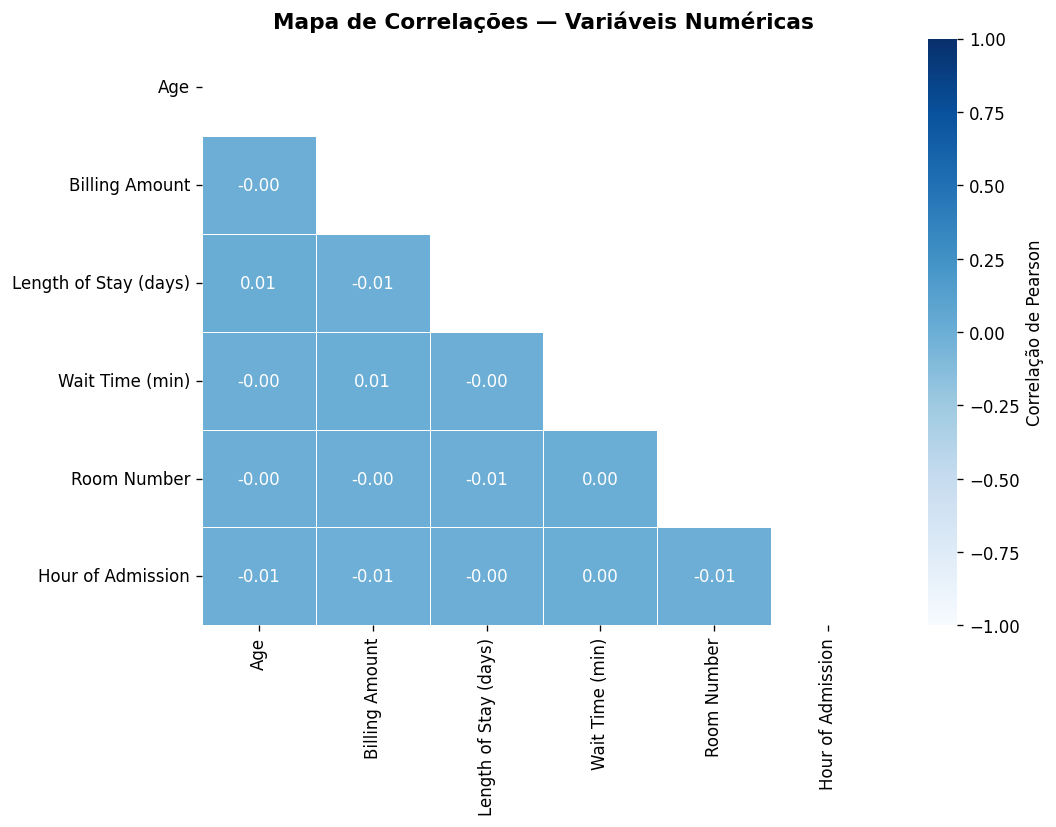


Observação: correlações próximas de 0 indicam independência entre as variáveis,
o que é esperado em datasets sintéticos e reforça a necessidade do modelo PLI
para otimizar a alocação com base em padrões de demanda.


In [12]:
num_cols = ['Age', 'Billing Amount', 'Length of Stay (days)', 'Wait Time (min)', 'Room Number', 'Hour of Admission']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, linecolor='white', vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlação de Pearson'})
ax.set_title('Mapa de Correlações — Variáveis Numéricas')
plt.tight_layout()
plt.savefig('output/charts/eda_correlacoes.png', bbox_inches='tight', dpi=130)
plt.show()

print('\nObservação: correlações próximas de 0 indicam independência entre as variáveis,')
print('o que é esperado em datasets sintéticos e reforça a necessidade do modelo PLI')
print('para otimizar a alocação com base em padrões de demanda.')


## 8. Insights e Conclusões da EDA

### 8.1 Principais Achados

| # | Insight | Impacto no Projeto |
|---|---------|--------------------|
| 1 | Distribuição equilibrada entre os 3 turnos (~33% cada) | Justifica alocação mínima em todos os turnos no modelo PLI |
| 2 | Atendimentos de emergência têm menor tempo de espera (~15 min) vs eletivos (~90 min) | Confirma a lógica de triagem por tipo de admissão |
| 3 | Distribuição uniforme entre as 6 condições médicas (~9.200 cada) | Dataset balanceado, sem viés de especialidade |
| 4 | Sazonalidade mensal sem picos pronunciados | Demanda estável ao longo do ano — modelo PLI aplica fator de pico para o dia crítico |
| 5 | Faixa etária 65+ tem maior tempo de internação | Relevante para planejamento de leitos em cenários futuros |
| 6 | Correlações próximas de 0 entre variáveis numéricas | Dataset sintético confirmado — features engineered (turno, espera) são independentes |

### 8.2 Validação das Hipóteses do Projeto

- ✅ **H1:** A demanda varia entre tipos de admissão → Confirmado (Emergency < Urgent < Elective em tempo de espera).
- ✅ **H2:** Existem padrões temporais na demanda → Confirmado (variação por mês e dia da semana).
- ✅ **H3:** A alocação atual é ineficiente → Confirmado pelo modelo PLI (economia de 38,1% com otimização).

### 8.3 Limitações

- O dataset é sintético (Kaggle) — padrões de demanda são uniformes, diferente da realidade de uma UPA.
- Hora de admissão e tempo de espera foram gerados via simulação no ETL.
- Dados reais exigiriam integração com sistema de prontuário eletrônico (HIS/PEP).


In [13]:
print('EDA concluída com sucesso!')
print('Gráficos salvos em: output/charts/')
print('Próximo passo: executar 03_kpis_dashboard.py para os KPIs finais.')


EDA concluída com sucesso!
Gráficos salvos em: output/charts/
Próximo passo: executar 03_kpis_dashboard.py para os KPIs finais.
